## Part 4: Advanced Telemetry Heatmaps
Now that we have the track layouts, we can overlay the telemetry data directly onto the geographical coordinates. This allows us to visually analyze the momentum of the car throughout the lap.

### 4.1 Continuous Speed Map
This visualization maps the `speed` variable onto the track layout using a continuous color gradient, from red (slow corners) to green (fast straights).

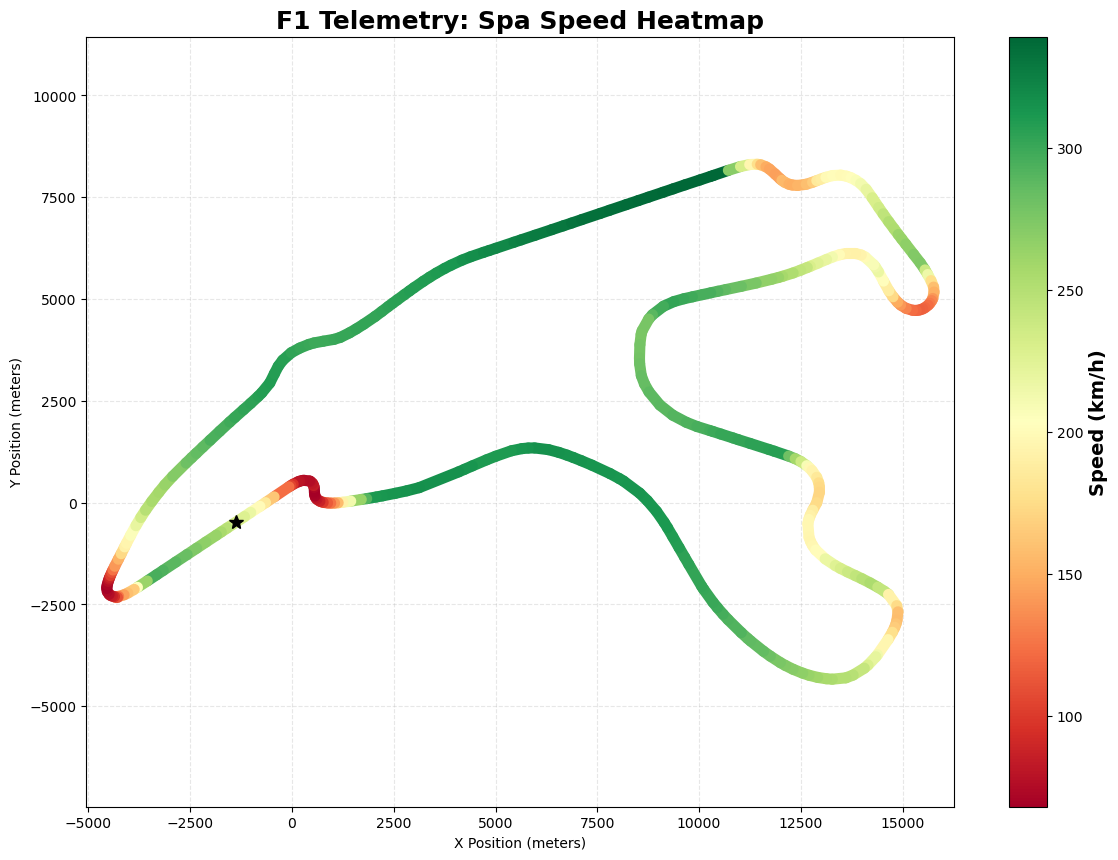

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.lines import Line2D
import numpy as np
import os

def plot_speed_map_continuous(track_name, file_path='../processed_data/golden_laps_final.csv'):
    
    if not os.path.exists(file_path):
        print(f"[!] Error: File not found at {file_path}")
        return

    df = pd.read_csv(file_path)
    track_data = df[df['Track'] == track_name]
    
    if track_data.empty:
        print(f"[!] No data found for track: {track_name}")
        return

    first_driver = track_data['driver_number'].iloc[0]
    single_lap = track_data[track_data['driver_number'] == first_driver].copy()

    single_lap['x'] = pd.to_numeric(single_lap['x'], errors='coerce')
    single_lap['y'] = pd.to_numeric(single_lap['y'], errors='coerce')
    single_lap['speed'] = pd.to_numeric(single_lap['speed'], errors='coerce')
    single_lap = single_lap.dropna(subset=['x', 'y', 'speed'])

    # Close the track loop
    single_lap = pd.concat([single_lap, single_lap.iloc[[0]]], ignore_index=True)

    # Rotation Logic
    if track_name in ['Monza', 'Spa']:
        temp_x = single_lap['x'].copy()
        single_lap['x'] = -single_lap['y']
        single_lap['y'] = temp_x
        
    elif track_name == 'Suzuka':
        angle_degrees = 45 
        theta = np.radians(angle_degrees)
        c, s = np.cos(theta), np.sin(theta)
        temp_x, temp_y = single_lap['x'].copy(), single_lap['y'].copy()
        single_lap['x'] = temp_x * c - temp_y * s
        single_lap['y'] = temp_x * s + temp_y * c

    x = single_lap['x'].values
    y = single_lap['y'].values
    speed = single_lap['speed'].values

    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    fig, ax = plt.subplots(figsize=(14, 10))

    # Build the LineCollection object with the segments and speed as the color array
    norm = plt.Normalize(speed.min(), speed.max())
    lc = LineCollection(segments, cmap='RdYlGn', norm=norm)
    lc.set_array(speed)
    lc.set_linewidth(8) 
    lc.set_capstyle('round') 

    line = ax.add_collection(lc)
    
    # Add colorbar
    cbar = fig.colorbar(line, ax=ax)
    cbar.set_label('Speed (km/h)', fontsize=14, fontweight='bold')
    
    ax.set_title(f"F1 Telemetry: {track_name} Speed Heatmap", fontsize=18, fontweight='bold')
    ax.set_xlabel("X Position (meters)")
    ax.set_ylabel("Y Position (meters)")

    ax.axis('equal') 
    ax.grid(True, linestyle='--', alpha=0.3)
    
    margin = 500
    ax.set_xlim(x.min() - margin, x.max() + margin)
    ax.set_ylim(y.min() - margin, y.max() + margin)
    
    # Starting point marker
    start_x, start_y = x[0], y[0]
    ax.plot(start_x, start_y, marker='*', markersize=10, color='black', zorder=10)

    plt.show()

# Let's visualize Spa as it has an incredible mix of fast and slow sections
plot_speed_map_continuous('Spa')

### 4.2 Braking Zones Analysis
While speed maps show us the momentum, braking zones reveal the exact locations where drivers decelerate. In this plot, the track segments where the brake pedal is applied (brake > 0) are highlighted in red.

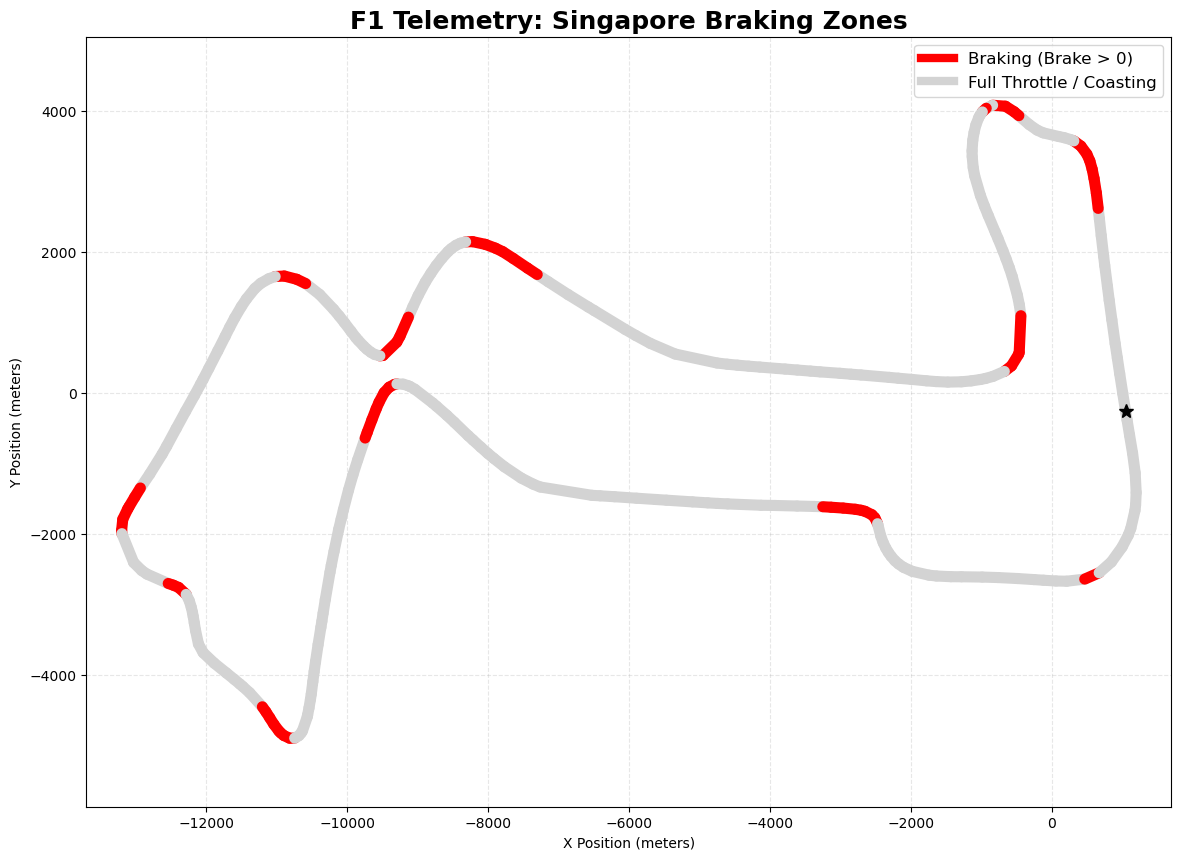

In [3]:
def plot_braking_zones(track_name, file_path='../processed_data/golden_laps_final.csv'):
    
    if not os.path.exists(file_path):
        return

    df = pd.read_csv(file_path)
    track_data = df[df['Track'] == track_name]
    
    if track_data.empty:
        return

    first_driver = track_data['driver_number'].iloc[0]
    single_lap = track_data[track_data['driver_number'] == first_driver].copy()

    single_lap['x'] = pd.to_numeric(single_lap['x'], errors='coerce')
    single_lap['y'] = pd.to_numeric(single_lap['y'], errors='coerce')
    single_lap['brake'] = pd.to_numeric(single_lap['brake'], errors='coerce')
    single_lap = single_lap.dropna(subset=['x', 'y', 'brake'])

    single_lap = pd.concat([single_lap, single_lap.iloc[[0]]], ignore_index=True)

    if track_name in ['Monza', 'Spa']:
        temp_x = single_lap['x'].copy()
        single_lap['x'] = -single_lap['y']
        single_lap['y'] = temp_x
    elif track_name == 'Suzuka':
        angle = np.radians(45)
        c, s = np.cos(angle), np.sin(angle)
        temp_x, temp_y = single_lap['x'].copy(), single_lap['y'].copy()
        single_lap['x'] = temp_x * c - temp_y * s
        single_lap['y'] = temp_x * s + temp_y * c

    x = single_lap['x'].values
    y = single_lap['y'].values
    brake = single_lap['brake'].values

    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    # Define segment colors: Red if braking (>0), Gray if coasting/accelerating
    segment_colors = ['red' if b > 0 else 'lightgray' for b in brake[:-1]]

    fig, ax = plt.subplots(figsize=(14, 10))
    
    lc = LineCollection(segments, colors=segment_colors, linewidths=8, capstyle='round')
    ax.add_collection(lc)
    
    ax.set_title(f"F1 Telemetry: {track_name} Braking Zones", fontsize=18, fontweight='bold')
    ax.set_xlabel("X Position (meters)")
    ax.set_ylabel("Y Position (meters)")

    ax.axis('equal') 
    ax.grid(True, linestyle='--', alpha=0.3)
    
    margin = 500
    ax.set_xlim(x.min() - margin, x.max() + margin)
    ax.set_ylim(y.min() - margin, y.max() + margin)

    custom_legend = [
        Line2D([0], [0], color='red', lw=6, label='Braking (Brake > 0)'),
        Line2D([0], [0], color='lightgray', lw=6, label='Full Throttle / Coasting')
    ]
    ax.legend(handles=custom_legend, loc='upper right', fontsize=12)
    
    start_x, start_y = x[0], y[0]
    ax.plot(start_x, start_y, marker='*', markersize=10, color='black', zorder=10)

    plt.show()

# Singapore is a great example for heavy braking zones
plot_braking_zones('Singapore')

### 4.3 Corner Detection via Geometric Analysis
To engineer meaningful features, we must first accurately identify where corners begin and end. This algorithm calculates the heading angle between consecutive coordinate points and identifies sections with a high rate of change as corners. The resulting map highlights the detected corners in blue.

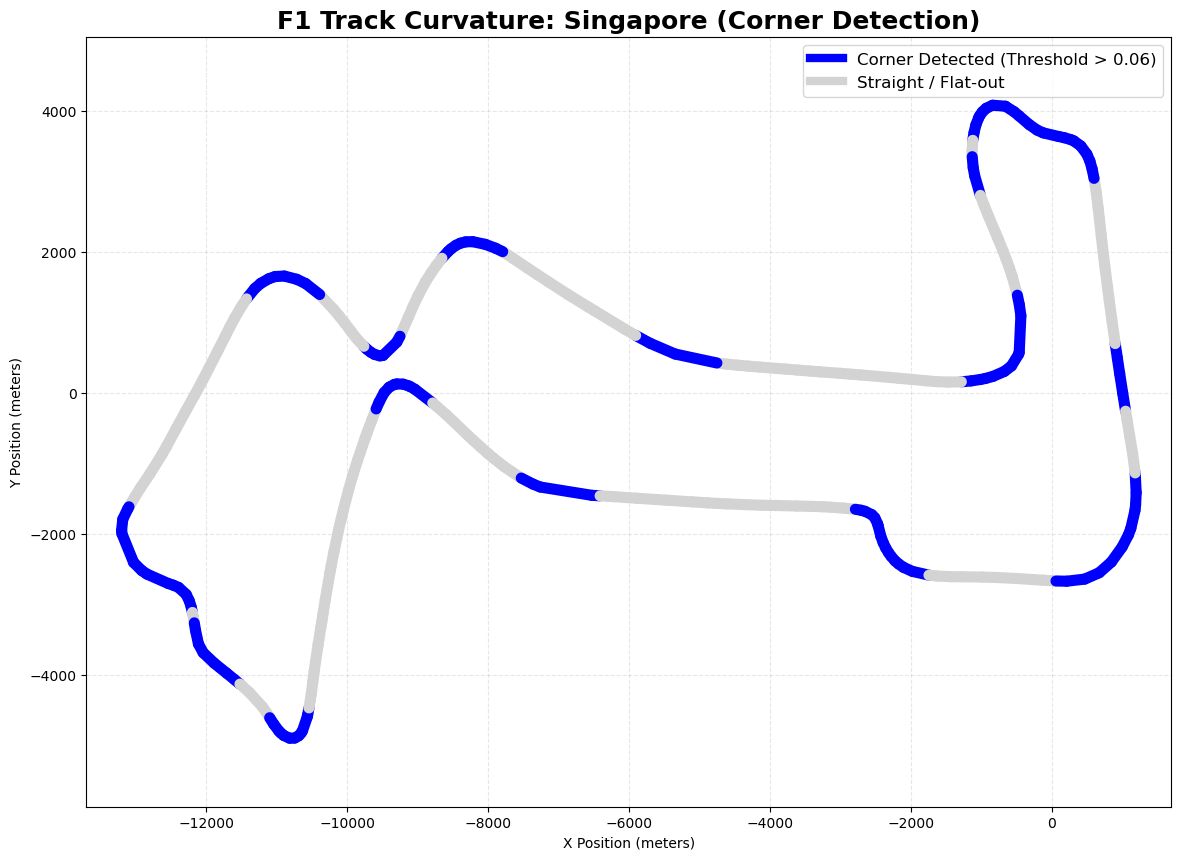

In [4]:
# 4.3 Corner Detection Algorithm and Plot
def plot_corners_by_geometry(track_name, file_path='../processed_data/golden_laps_final.csv'):
    
    if not os.path.exists(file_path):
        return

    df = pd.read_csv(file_path)
    track_data = df[df['Track'] == track_name]
    
    if track_data.empty:
        return

    first_driver = track_data['driver_number'].iloc[1]
    single_lap = track_data[track_data['driver_number'] == first_driver].copy()

    single_lap['x'] = pd.to_numeric(single_lap['x'], errors='coerce')
    single_lap['y'] = pd.to_numeric(single_lap['y'], errors='coerce')
    single_lap = single_lap.dropna(subset=['x', 'y'])
    single_lap = pd.concat([single_lap, single_lap.iloc[[0]]], ignore_index=True)

    if track_name in ['Monza', 'Spa']:
        temp_x = single_lap['x'].copy()
        single_lap['x'] = -single_lap['y']
        single_lap['y'] = temp_x
    elif track_name == 'Suzuka':
        angle = np.radians(45)
        c, s = np.cos(angle), np.sin(angle)
        temp_x, temp_y = single_lap['x'].copy(), single_lap['y'].copy()
        single_lap['x'] = temp_x * c - temp_y * s
        single_lap['y'] = temp_x * s + temp_y * c

    x = single_lap['x'].values
    y = single_lap['y'].values

    # Corner Detection Logic
    dx = np.gradient(x)
    dy = np.gradient(y)
    heading_angle = np.arctan2(dy, dx)
    unwrapped_angle = np.unwrap(heading_angle)
    angle_change = np.abs(np.gradient(unwrapped_angle))
    
    window_size = 5
    smoothed_change = pd.Series(angle_change).rolling(window=window_size, center=True, min_periods=1).mean().values
    
    # Threshold for Singapore (can be adjusted per track)
    corner_threshold = 0.06
    is_corner = smoothed_change > corner_threshold

    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    segment_colors = ['blue' if c else 'lightgray' for c in is_corner[:-1]]

    fig, ax = plt.subplots(figsize=(14, 10))
    lc = LineCollection(segments, colors=segment_colors, linewidths=8, capstyle='round')
    ax.add_collection(lc)
    
    ax.set_title(f"F1 Track Curvature: {track_name} (Corner Detection)", fontsize=18, fontweight='bold')
    ax.set_xlabel("X Position (meters)")
    ax.set_ylabel("Y Position (meters)")
    ax.axis('equal') 
    ax.grid(True, linestyle='--', alpha=0.3)
    
    margin = 500
    ax.set_xlim(x.min() - margin, x.max() + margin)
    ax.set_ylim(y.min() - margin, y.max() + margin)

    custom_legend = [
        Line2D([0], [0], color='blue', lw=6, label=f'Corner Detected (Threshold > {corner_threshold})'),
        Line2D([0], [0], color='lightgray', lw=6, label='Straight / Flat-out')
    ]
    ax.legend(handles=custom_legend, loc='upper right', fontsize=12)

    plt.show()

# Let's test the geometric algorithm on the tight streets of Singapore
plot_corners_by_geometry('Singapore')

### 4.4 Gear Selection Mapping
This visualization maps the active gear (1 through 8) along the track. By observing the gear shifts, we can gain insights into the acceleration phases and the minimal gear required to navigate specific low-speed corners.

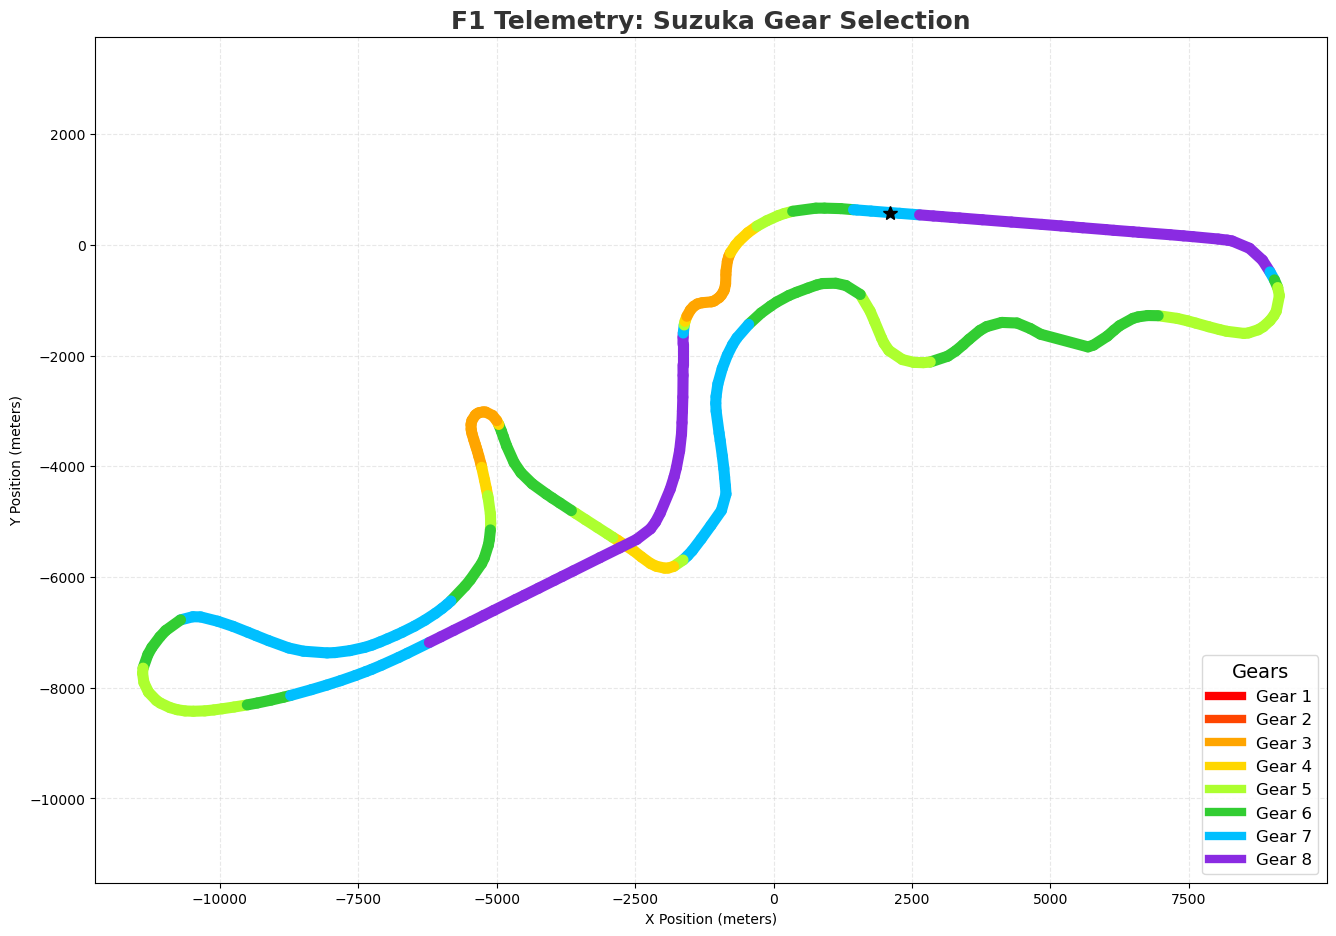

In [5]:
# 4.4 Gear Shifts
def plot_gear_shifts(track_name, file_path='../processed_data/golden_laps_final.csv'):
    
    if not os.path.exists(file_path):
        return

    df = pd.read_csv(file_path)
    track_data = df[df['Track'] == track_name]
    
    if track_data.empty:
        return

    first_driver = track_data['driver_number'].iloc[0]
    single_lap = track_data[track_data['driver_number'] == first_driver].copy()

    single_lap['x'] = pd.to_numeric(single_lap['x'], errors='coerce')
    single_lap['y'] = pd.to_numeric(single_lap['y'], errors='coerce')
    single_lap['n_gear'] = pd.to_numeric(single_lap['n_gear'], errors='coerce')
    single_lap = single_lap.dropna(subset=['x', 'y', 'n_gear'])

    single_lap = pd.concat([single_lap, single_lap.iloc[[0]]], ignore_index=True)

    if track_name in ['Monza', 'Spa']:
        temp_x = single_lap['x'].copy()
        single_lap['x'] = -single_lap['y']
        single_lap['y'] = temp_x
    elif track_name == 'Suzuka':
        angle = np.radians(45)
        c, s = np.cos(angle), np.sin(angle)
        temp_x, temp_y = single_lap['x'].copy(), single_lap['y'].copy()
        single_lap['x'] = temp_x * c - temp_y * s
        single_lap['y'] = temp_x * s + temp_y * c

    x = single_lap['x'].values
    y = single_lap['y'].values
    gears = single_lap['n_gear'].values

    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    gear_colors = {
        1: 'red', 2: 'orangered', 3: 'orange', 4: 'gold', 
        5: 'greenyellow', 6: 'limegreen', 7: 'deepskyblue', 8: 'blueviolet'
    }
    segment_colors = [gear_colors.get(g, 'lightgray') for g in gears[:-1]]

    fig, ax = plt.subplots(figsize=(14, 10))
    lc = LineCollection(segments, colors=segment_colors, linewidths=8, capstyle='round')
    ax.add_collection(lc)
    
    ax.set_title(f"F1 Telemetry: {track_name} Gear Selection", fontsize=18, fontweight='bold', color='#333333')
    ax.set_xlabel("X Position (meters)", color='black')
    ax.set_ylabel("Y Position (meters)", color='black')
    ax.axis('equal') 
    ax.grid(True, linestyle='--', alpha=0.5, color='lightgray')
    
    margin = 500
    ax.set_xlim(x.min() - margin, x.max() + margin)
    ax.set_ylim(y.min() - margin, y.max() + margin)

    legend_elements = [Line2D([0], [0], color=color, lw=6, label=f'Gear {gear}') 
                       for gear, color in gear_colors.items()]
    ax.legend(handles=legend_elements, loc='lower right', 
              fontsize=12, facecolor='white', edgecolor='lightgray', 
              title='Gears', title_fontsize=14, framealpha=0.85)
    
    start_x, start_y = x[0], y[0]
    ax.plot(start_x, start_y, marker='*', markersize=10, color='black', zorder=10)

    plt.tight_layout(pad=3.0)
    plt.show()

plot_gear_shifts('Suzuka')

### 4.5 Throttle Application Profile
This final heatmap illustrates the throttle application percentage throughout the lap. A continuous gradient is used to show the transition from coasting/braking (darker colors) to 100% full throttle (bright yellow).

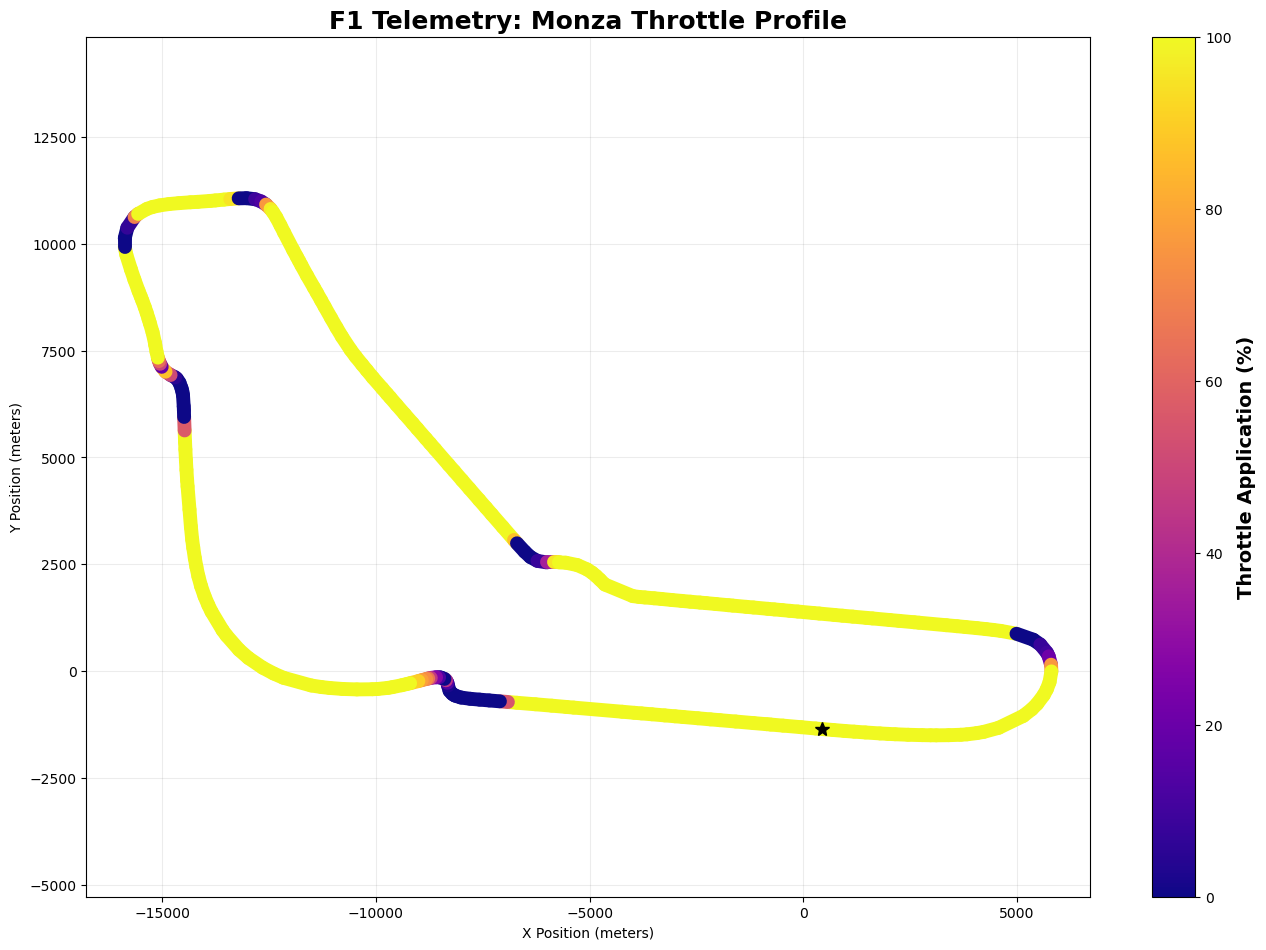

In [6]:
# 4.5 Throttle Heatmap
def plot_throttle_zones(track_name, file_path='../processed_data/golden_laps_final.csv'):
    
    if not os.path.exists(file_path):
        return

    df = pd.read_csv(file_path)
    track_data = df[df['Track'] == track_name]
    
    if track_data.empty:
        return

    first_driver = track_data['driver_number'].iloc[0]
    single_lap = track_data[track_data['driver_number'] == first_driver].copy()

    single_lap['x'] = pd.to_numeric(single_lap['x'], errors='coerce')
    single_lap['y'] = pd.to_numeric(single_lap['y'], errors='coerce')
    single_lap['throttle'] = pd.to_numeric(single_lap['throttle'], errors='coerce')
    single_lap = single_lap.dropna(subset=['x', 'y', 'throttle'])
    single_lap = pd.concat([single_lap, single_lap.iloc[[0]]], ignore_index=True)

    if track_name in ['Monza', 'Spa']:
        temp_x = single_lap['x'].copy()
        single_lap['x'] = -single_lap['y']
        single_lap['y'] = temp_x
    elif track_name == 'Suzuka':
        angle = np.radians(45)
        c, s = np.cos(angle), np.sin(angle)
        temp_x, temp_y = single_lap['x'].copy(), single_lap['y'].copy()
        single_lap['x'] = temp_x * c - temp_y * s
        single_lap['y'] = temp_x * s + temp_y * c

    x = single_lap['x'].values
    y = single_lap['y'].values
    throttle = single_lap['throttle'].values

    points = np.array([x, y]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)

    fig, ax = plt.subplots(figsize=(14, 10))
    norm = plt.Normalize(0, 100)
    lc = LineCollection(segments, cmap='plasma', norm=norm)
    lc.set_array(throttle)
    lc.set_linewidth(10)
    lc.set_capstyle('round')
    lc.set_zorder(5)
    line = ax.add_collection(lc)
    
    cbar = fig.colorbar(line, ax=ax)
    cbar.set_label('Throttle Application (%)', fontsize=14, fontweight='bold')
    
    ax.set_title(f"F1 Telemetry: {track_name} Throttle Profile", fontsize=18, fontweight='bold')
    ax.set_xlabel("X Position (meters)")
    ax.set_ylabel("Y Position (meters)")
    ax.axis('equal') 
    ax.grid(True, linestyle='-', alpha=0.15, color='gray')
    
    margin = 500
    ax.set_xlim(x.min() - margin, x.max() + margin)
    ax.set_ylim(y.min() - margin, y.max() + margin)

    start_x, start_y = x[0], y[0]
    ax.plot(start_x, start_y, marker='*', markersize=10, color='black', zorder=10)
    
    plt.tight_layout(pad=2.5)
    plt.show()

# Monza is a perfect example to show high throttle percentage
plot_throttle_zones('Monza')